In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
# import geopandas as gpd
import pandas as pd
import seaborn as sns
from scipy.stats import qmc
from ipywidgets import IntProgress

# importeren van ewatercycle
import ewatercycle
import ewatercycle.models
import ewatercycle.forcing

In [2]:
basin_name = "Frans"

# tijdsinterval
start_datum = "2017-01-01"
eind_datum = "2021-12-31"

# route naar shape file
shapefile = Path.home() / "BEP-Julian" / "BEP-Julian" / "Frans_model" / "Frans.shp"

# route naar forcing ERA5 data
forcing_route = Path.home() / "BEP-Julian" / "BEP-Julian" / "Forcing" / "ERA5_2017_2021"/ "work" / "diagnostic" / "script"
forcing_route.mkdir(exist_ok=True)

# route naar hbv 
HBV_model = Path.home() / "BEP-Julian" / "BEP-Julian" / "Frans_model" / "hbv_bmi"
HBV_model.mkdir(exist_ok=True)

# route naar discharge file, van Maxime
discharge_file = Path.home() / "BEP-Julian" / "BEP-Julian" / "Frans_model" / "Frans.csv"

# stroomgebied oppervlakte im km^2
frans_area = 7.638586e+03 

                          Date    Value
9144 2017-01-01 00:00:00+00:00  138.547
9145 2017-01-02 00:00:00+00:00  132.485
9146 2017-01-03 00:00:00+00:00  162.360
9147 2017-01-04 00:00:00+00:00  179.180
9148 2017-01-05 00:00:00+00:00  196.999


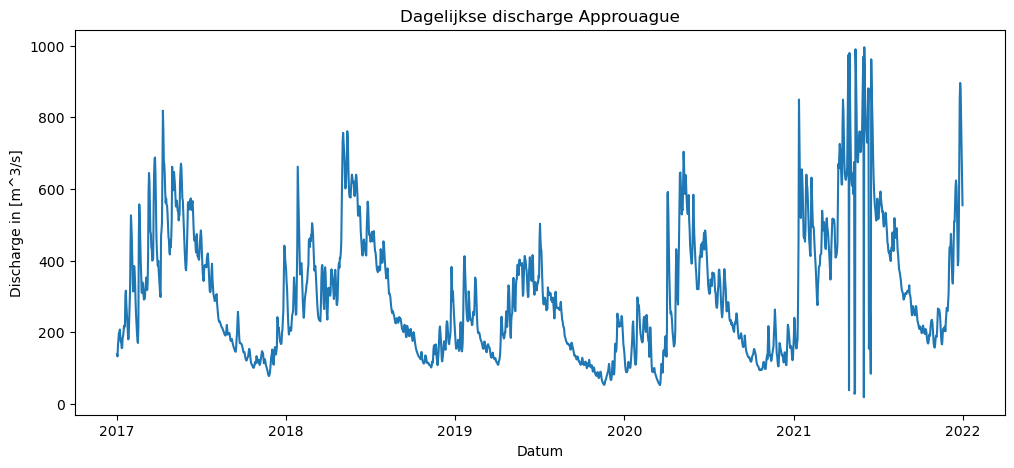

In [3]:
df = pd.read_csv(discharge_file, delimiter=';')
df["Value"] = df["Value"]/1000 # excel formatting van engels naar nederlands. Kan in excel worden opgelost maar ik ben lui
# df = pd.read_csv(discharge_file, delimiter=';', header = 0,  index_col=[0], parse_dates = True)
df.replace(999000, np.nan, inplace=True)
# print(df)

df["Date"] = pd.to_datetime(df["Date"], utc = True)
# print(df)
# print("Max = ",df["Value"].max())

# start_date = pd.to_datetime(start_datum.replace("Z", ""))
# end_date = pd.to_datetime(eind_datum.replace("Z", ""))

start_date = pd.to_datetime(start_datum, utc=True)
end_date = pd.to_datetime(eind_datum, utc=True)

df = df[
    (df["Date"] >= start_date) &
    (df["Date"] <= end_date)
].copy()

start_time_utc = start_date.strftime("%Y-%m-%dT%H:%M:%SZ")
end_time_utc = end_date.strftime("%Y-%m-%dT%H:%M:%SZ")

flow = pd.DataFrame(data=df["Value"].values, index=df["Date"], columns=['Q'])
flow.index = pd.to_datetime(flow.index).tz_localize(None)

print(df.head())

plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Value"])
plt.xlabel("Datum")
plt.ylabel("Discharge in [m^3/s]")
plt.title("Dagelijkse discharge Approuague")
plt.show()

In [4]:
df["Date"] = pd.to_datetime(df["Date"]).dt.tz_localize(None)
df["Date"] = df["Date"].dt.normalize()  
print(df)

            Date    Value
9144  2017-01-01  138.547
9145  2017-01-02  132.485
9146  2017-01-03  162.360
9147  2017-01-04  179.180
9148  2017-01-05  196.999
...          ...      ...
10965 2021-12-27  875.271
10966 2021-12-28  799.095
10967 2021-12-29  713.189
10968 2021-12-30  626.093
10969 2021-12-31  554.588

[1826 rows x 2 columns]


In [5]:
start_calibration = '2017-01-01'
end_calibration = '2021-12-31'

In [6]:
ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=forcing_route)

In [7]:
evap = ERA5_forcing.to_xarray()["evspsblpot"] #units: kg m^-2 s^-1 = mm/s, gesampled per dag
prec = ERA5_forcing.to_xarray()["pr"] #units: kg m^-2 s^-1 = mm/s, gesampled per dag

In [8]:
print(f"The forcing object you created: \n {ERA5_forcing}")

The forcing object you created: 
 start_time='2017-01-01T00:00:00Z' end_time='2021-12-31T00:00:00Z' directory=PosixPath('/home/julian/BEP-Julian/BEP-Julian/Forcing/ERA5_2017_2021/work/diagnostic/script') shape=PosixPath('/home/julian/BEP-Julian/BEP-Julian/Forcing/ERA5_2017_2021/work/diagnostic/script/Frans.shp') filenames={'pr': 'OBS6_ERA5_reanaly_1_day_pr_2017-2021.nc', 'tas': 'OBS6_ERA5_reanaly_1_day_tas_2017-2021.nc', 'rsds': 'OBS6_ERA5_reanaly_1_day_rsds_2017-2021.nc', 'evspsblpot': 'Derived_Makkink_evspsblpot.nc'}


## RMSE functie

In [9]:
# Van Ischa om een goede eerste fit te krijgen
def RMSE(output, observed, start, end):
    start = pd.to_datetime(start)
    end = pd.to_datetime(end)
    
    output.index = pd.to_datetime(output.index)
    observed.index = pd.to_datetime(observed.index)

    hydro_data = pd.concat([output.reindex(observed.index, method='ffill'), observed], axis=1, keys=['model', 'observation'])
    hydro_data = hydro_data.dropna()
    
    hydro_data = hydro_data[(hydro_data.index > start) & (hydro_data.index < end)]
    
    squarediff = (hydro_data['model'] - hydro_data['observation']) ** 2
    rootMeanSquareDiff = np.sqrt(np.mean(squarediff))
    
    return rootMeanSquareDiff

## NSE functie

In [10]:
def NSE(output, observed, start, end):
    start = pd.to_datetime(start)
    end = pd.to_datetime(end)
    
    output.index = pd.to_datetime(output.index)
    observed.index = pd.to_datetime(observed.index)

    hydro_data = pd.concat([output.reindex(observed.index, method='ffill'), observed], axis=1, keys=['model', 'observation'])
    hydro_data = hydro_data.dropna()
    
    hydro_data = hydro_data[(hydro_data.index > start) & (hydro_data.index < end)]

    #hier de formule van NSE invoegen
    
    top = np.sum((hydro_data['observation'] - hydro_data['model'])**2)

    bottom = np.sum((hydro_data['observation']- hydro_data['observation'].mean())**2)

    nse = 1 - (top / bottom)
    
    return nse

## log NSE functie

In [11]:
def logNSE(output, observed, start, end):
    start = pd.to_datetime(start)
    end = pd.to_datetime(end)
    
    output.index = pd.to_datetime(output.index)
    observed.index = pd.to_datetime(observed.index)

    hydro_data = pd.concat([output.reindex(observed.index, method='ffill'), observed], axis=1, keys=['model', 'observation'])
    hydro_data = hydro_data.dropna()
    
    hydro_data = hydro_data[(hydro_data.index > start) & (hydro_data.index < end)]

    #hier de formule van NSE invoegen
    
    top = np.sum((np.log10(hydro_data['observation']) - np.log10(hydro_data['model']))**2)

    bottom = np.sum((np.log10(hydro_data['observation']) - np.log10(hydro_data['observation']).mean())**2)

    lognse = 1 - (top / bottom)
    
    return lognse

In [12]:
N = 2000 # 50 voor show, 200 voor test, 2000 voor kalibratie

In [13]:
s_0 = np.array([0,  100,  0,  5,  0])

# Define parameters and their corresponding boundary values 
param_names = ["Imax", "Ce", "Sumax", "Beta", "Pmax", "Tlag", "Kf", "Ks", "FM"]
param_mins = np.array([0, 0.2, 40, 0.5, 0.001, 1, 0.01, 0.0001, 0.0])
param_maxs = np.array([8, 1, 800, 4, 0.3, 10, 0.1, 0.01, 0.000001])

#Fill the parameters array with N random values between each minimum and maximum 
sampler = qmc.LatinHypercube(d=len(param_names))
sample = sampler.random(n=N)
parameters = qmc.scale(sample, param_mins, param_maxs)
print(list(zip(param_names, np.round(parameters[0], decimals=3))))

[('Imax', 1.384), ('Ce', 0.614), ('Sumax', 148.85), ('Beta', 0.985), ('Pmax', 0.239), ('Tlag', 3.479), ('Kf', 0.031), ('Ks', 0.001), ('FM', 0.0)]


In [14]:
def mmday_to_m3s(Q_sim_mmday, frans_area):
    return (Q_sim_mmday * frans_area) / 86.4

## RMSE

In [15]:
ensemble = []

for counter in range(N): 
    ensemble.append(ewatercycle.models.HBVLocal(forcing=ERA5_forcing))
    config_file, _ = ensemble[counter].setup(parameters = parameters[counter],  initial_storage=s_0, cfg_dir = HBV_model)
    ensemble[counter].initialize(config_file)

In [16]:
f = IntProgress(min=0, max=N)
display(f)

# Array to store level of fit values
objectives_RMSE = []

# Loop over ensemble members
for ensembleMember in ensemble:
    Q_m_RMSE = []
    time_RMSE = []
    while ensembleMember.time < ensembleMember.end_time:
        ensembleMember.update()
        discharge_this_timestep = ensembleMember.get_value("Q")
        Q_m_RMSE.append(discharge_this_timestep[0])
        time_RMSE.append(ensembleMember.time_as_datetime)

    # Create DataFrame for model results
    Q_m_RMSE = mmday_to_m3s(np.array(Q_m_RMSE), frans_area)
    discharge_dataframe = pd.DataFrame({'model output': Q_m_RMSE}, index=pd.to_datetime(time_RMSE))
    
    # Calculate the model of best-fit function
    fit_RMSE = RMSE(discharge_dataframe['model output'], flow['Q'], start_calibration, end_calibration)
    objectives_RMSE.append(fit_RMSE)

    # Free up memory
    del Q_m_RMSE, time_RMSE, discharge_dataframe, fit_RMSE
    f.value += 1

# Clean up models to save memory
for ensembleMember in ensemble:
    ensembleMember.finalize()

IntProgress(value=0, max=2000)

In [36]:
parameters_RMSE_index = np.argmin(np.array(objectives_RMSE))
if np.min(np.array(objectives_RMSE)) == np.inf:
    print("No real parameter is chosen")

parameters_RMSE = parameters[parameters_RMSE_index]

print(f'The best RMSE parameters are: {list(zip(param_names, np.round(parameters_RMSE, decimals=3)))}')
print(parameters_RMSE)
print(len(parameters))
print(np.min(np.array(objectives_RMSE)))

The best RMSE parameters are: [('Imax', 0.772), ('Ce', 0.293), ('Sumax', 79.614), ('Beta', 0.553), ('Pmax', 0.008), ('Tlag', 4.685), ('Kf', 0.016), ('Ks', 0.006), ('FM', 0.0)]
[ 0.77241331  0.29269629 79.61362405  0.55344546  0.00757638  4.68474362
  0.016498    0.00616083  0.00000035]
2000
131.0858924114269


In [18]:
rmse = np.array(objectives_RMSE)

best_10_indices = np.argpartition(rmse, 10)[:10]
best_10_indices = best_10_indices[np.argsort(rmse[best_10_indices])]
best_10_parameters = parameters[best_10_indices]

param_boundary = [[]]
for i in range(9):
    # print(i)
    param_min = np.min(best_10_parameters[:,i])
    param_max = np.max(best_10_parameters[:,i])
    param_boundary.append([param_min, param_max])

print(param_boundary)

# print(best_10_parameters[:,7])
# print(best_10_parameters)

[[], [0.19381326986034575, 7.542010466857127], [0.27820043604297895, 0.509867117042146], [56.125409561544394, 774.7439629559648], [0.5140922897565736, 0.9161203726258026], [0.002453429201468487, 0.2763655636711142], [1.7826772022566313, 9.144594089724386], [0.012748074024632882, 0.03811651806510729], [0.002310459398782867, 0.009155138502363628], [1.0308092540232808e-07, 9.926979657546508e-07]]


## NSE

In [19]:
ensemble = []

for counter in range(N): 
    ensemble.append(ewatercycle.models.HBVLocal(forcing=ERA5_forcing))
    config_file, _ = ensemble[counter].setup(parameters = parameters[counter],  initial_storage=s_0, cfg_dir = HBV_model)
    ensemble[counter].initialize(config_file)

In [20]:
f = IntProgress(min=0, max=N)
display(f)

# Array to store level of fit values
objectives_NSE = []

# Loop over ensemble members
for ensembleMember in ensemble:
    Q_m_NSE = []
    time_NSE = []
    while ensembleMember.time < ensembleMember.end_time:
        ensembleMember.update()
        discharge_this_timestep = ensembleMember.get_value("Q")
        Q_m_NSE.append(discharge_this_timestep[0])
        time_NSE.append(ensembleMember.time_as_datetime)

    # Create DataFrame for model results
    Q_m_NSE = mmday_to_m3s(np.array(Q_m_NSE), frans_area)
    discharge_dataframe = pd.DataFrame({'model output': Q_m_NSE}, index=pd.to_datetime(time_NSE))
    
    # Calculate the model of best-fit function
    fit_NSE = NSE(discharge_dataframe['model output'], flow['Q'], start_calibration, end_calibration)
    objectives_NSE.append(fit_NSE)

    # Free up memory
    del Q_m_NSE, time_NSE, discharge_dataframe, fit_NSE
    f.value += 1

# Clean up models to save memory
for ensembleMember in ensemble:
    ensembleMember.finalize()

IntProgress(value=0, max=2000)

In [35]:
parameters_NSE_index = np.argmax(np.array(objectives_NSE))
if np.min(np.array(objectives_NSE)) == np.inf:
    print("No real parameter is chosen")

parameters_NSE = parameters[parameters_NSE_index]

print(f'The best NSE parameters are: {list(zip(param_names, np.round(parameters_NSE, decimals=3)))}')
print(parameters_NSE)
print(len(parameters))
print(np.max(np.array(objectives_NSE)))

The best NSE parameters are: [('Imax', 0.772), ('Ce', 0.293), ('Sumax', 79.614), ('Beta', 0.553), ('Pmax', 0.008), ('Tlag', 4.685), ('Kf', 0.016), ('Ks', 0.006), ('FM', 0.0)]
[ 0.77241331  0.29269629 79.61362405  0.55344546  0.00757638  4.68474362
  0.016498    0.00616083  0.00000035]
2000
0.46536597745897934


In [22]:
nse = np.array(objectives_NSE)

best_10_indices = np.argpartition(nse, 10)[:10]
best_10_indices = best_10_indices[np.argsort(nse[best_10_indices])]
best_10_parameters = parameters[best_10_indices]

param_boundary = [[]]
for i in range(9):
    # print(i)
    param_min = np.min(best_10_parameters[:,i])
    param_max = np.max(best_10_parameters[:,i])
    param_boundary.append([param_min, param_max])

print(param_boundary)

# print(best_10_parameters[:,7])
# print(best_10_parameters)

[[], [0.16778641470691513, 7.273814641199959], [0.20263097615040637, 0.9729406075815776], [61.63095042187869, 775.3241237018942], [0.5930704992517336, 3.9587549925110874], [0.025081065506995934, 0.25015683643637127], [1.2892126442201728, 9.48245009333376], [0.015021020882831086, 0.09794393311912228], [0.0003451352334943855, 0.00860276992733848], [2.2556102123543256e-08, 9.811821447569483e-07]]


## log NSE

In [23]:
ensemble = []

for counter in range(N): 
    ensemble.append(ewatercycle.models.HBVLocal(forcing=ERA5_forcing))
    config_file, _ = ensemble[counter].setup(parameters = parameters[counter],  initial_storage=s_0, cfg_dir = HBV_model)
    ensemble[counter].initialize(config_file)

In [24]:
f = IntProgress(min=0, max=N)
display(f)

# Array to store level of fit values
objectives_logNSE = []

# Loop over ensemble members
for ensembleMember in ensemble:
    Q_m_logNSE = []
    time_logNSE = []
    while ensembleMember.time < ensembleMember.end_time:
        ensembleMember.update()
        discharge_this_timestep = ensembleMember.get_value("Q")
        Q_m_logNSE.append(discharge_this_timestep[0])
        time_logNSE.append(ensembleMember.time_as_datetime)

    # Create DataFrame for model results
    Q_m_logNSE = mmday_to_m3s(np.array(Q_m_logNSE), frans_area)
    discharge_dataframe = pd.DataFrame({'model output': Q_m_logNSE}, index=pd.to_datetime(time_logNSE))
    
    # Calculate the model of best-fit function
    fit_logNSE = logNSE(discharge_dataframe['model output'], flow['Q'], start_calibration, end_calibration)
    objectives_logNSE.append(fit_logNSE)

    # Free up memory
    del Q_m_logNSE, time_logNSE, discharge_dataframe, fit_logNSE
    f.value += 1

# Clean up models to save memory
for ensembleMember in ensemble:
    ensembleMember.finalize()

IntProgress(value=0, max=2000)

In [40]:
parameters_logNSE_index = np.argmax(np.array(objectives_logNSE))
if np.min(np.array(objectives_logNSE)) == np.inf:
    print("No real parameter is chosen")

parameters_logNSE = parameters[parameters_logNSE_index]

print(f'The best logNSE parameters are: {list(zip(param_names, np.round(parameters_logNSE, decimals=3)))}')
print(parameters_logNSE)
print(len(parameters))
print(np.max(np.array(objectives_logNSE)))

The best logNSE parameters are: [('Imax', 3.493), ('Ce', 0.485), ('Sumax', 151.982), ('Beta', 0.845), ('Pmax', 0.237), ('Tlag', 1.783), ('Kf', 0.017), ('Ks', 0.006), ('FM', 0.0)]
[  3.49259766   0.48486438 151.98197183   0.84452696   0.23730761
   1.7826772    0.01668441   0.00572176   0.0000005 ]
2000
0.5399806473033747


In [26]:
lognse = np.array(objectives_logNSE)

best_10_indices = np.argpartition(lognse, 10)[:10]
best_10_indices = best_10_indices[np.argsort(lognse[best_10_indices])]
best_10_parameters = parameters[best_10_indices]

param_boundary = [[]]
for i in range(9):
    # print(i)
    param_min = np.min(best_10_parameters[:,i])
    param_max = np.max(best_10_parameters[:,i])
    param_boundary.append([param_min, param_max])

print(param_boundary)

# print(best_10_parameters[:,7])
# print(best_10_parameters)

[[], [0.4322429249011303, 5.667639191566324], [0.20350983828411906, 0.308693544456858], [137.80277940870002, 775.3241237018942], [2.337735111138782, 3.9587549925110874], [0.003572700399570629, 0.20392458364022736], [1.194286165773987, 8.925851611519274], [0.056332136742169046, 0.09680303017208083], [0.0002415966167743942, 0.00879623877228645], [2.884984062909127e-08, 9.907909056502103e-07]]


## Visualiseren

run rmse

In [27]:
model = ewatercycle.models.HBV(forcing=ERA5_forcing)

config_file, _ = model.setup(parameters=parameters_RMSE, initial_storages=s_0, cfg_dir=HBV_model)

model.initialize(config_file)
Q_m = []
time = []

while model.time < model.end_time:
    model.update()
    Q_m.append(model.get_value("Q")[0])
    time.append(pd.Timestamp(model.time_as_datetime))

model.finalize()

In [28]:
model_output_mmday = pd.Series(data=Q_m, name="Modelled discharge", index=time)
# print(model_output_mmday.max())
model_output_m3s_RMSE = model_output_mmday * frans_area * 1000 / 86400

observed_output = pd.Series(data=df["Value"].to_numpy(), name="Observed discharge", index=df["Date"])
print(model_output_m3s_RMSE)

2017-01-02 12:00:00      0.000044
2017-01-03 12:00:00      0.691499
2017-01-04 12:00:00      3.308938
2017-01-05 12:00:00      8.739335
2017-01-06 12:00:00     15.725767
                          ...    
2021-12-27 12:00:00    367.275043
2021-12-28 12:00:00    375.199326
2021-12-29 12:00:00    378.795303
2021-12-30 12:00:00    379.262352
2021-12-31 12:00:00    380.060516
Name: Modelled discharge, Length: 1825, dtype: float64


run nse

In [29]:
model = ewatercycle.models.HBV(forcing=ERA5_forcing)

config_file, _ = model.setup(parameters=parameters_NSE, initial_storages=s_0, cfg_dir=HBV_model)

model.initialize(config_file)
Q_m = []
time = []

while model.time < model.end_time:
    model.update()
    Q_m.append(model.get_value("Q")[0])
    time.append(pd.Timestamp(model.time_as_datetime))

model.finalize()

In [30]:
model_output_mmday = pd.Series(data=Q_m, name="Modelled discharge", index=time)
# print(model_output_mmday.max())
model_output_m3s_NSE = model_output_mmday * frans_area * 1000 / 86400
print(model_output_m3s_NSE)

2017-01-02 12:00:00      0.000044
2017-01-03 12:00:00      0.691499
2017-01-04 12:00:00      3.308938
2017-01-05 12:00:00      8.739335
2017-01-06 12:00:00     15.725767
                          ...    
2021-12-27 12:00:00    367.275043
2021-12-28 12:00:00    375.199326
2021-12-29 12:00:00    378.795303
2021-12-30 12:00:00    379.262352
2021-12-31 12:00:00    380.060516
Name: Modelled discharge, Length: 1825, dtype: float64


run lognse

In [31]:
model = ewatercycle.models.HBV(forcing=ERA5_forcing)

config_file, _ = model.setup(parameters=parameters_logNSE, initial_storages=s_0, cfg_dir=HBV_model)

model.initialize(config_file)
Q_m = []
time = []

while model.time < model.end_time:
    model.update()
    Q_m.append(model.get_value("Q")[0])
    time.append(pd.Timestamp(model.time_as_datetime))

model.finalize()

In [32]:
model_output_mmday = pd.Series(data=Q_m, name="Modelled discharge", index=time)
# print(model_output_mmday.max())
model_output_m3s_logNSE = model_output_mmday * frans_area * 1000 / 86400
print(model_output_m3s_logNSE)

2017-01-02 12:00:00      0.003538
2017-01-03 12:00:00      1.235178
2017-01-04 12:00:00      4.034127
2017-01-05 12:00:00      7.885892
2017-01-06 12:00:00     11.696798
                          ...    
2021-12-27 12:00:00    392.596824
2021-12-28 12:00:00    391.644025
2021-12-29 12:00:00    389.653882
2021-12-30 12:00:00    393.871647
2021-12-31 12:00:00    398.694477
Name: Modelled discharge, Length: 1825, dtype: float64


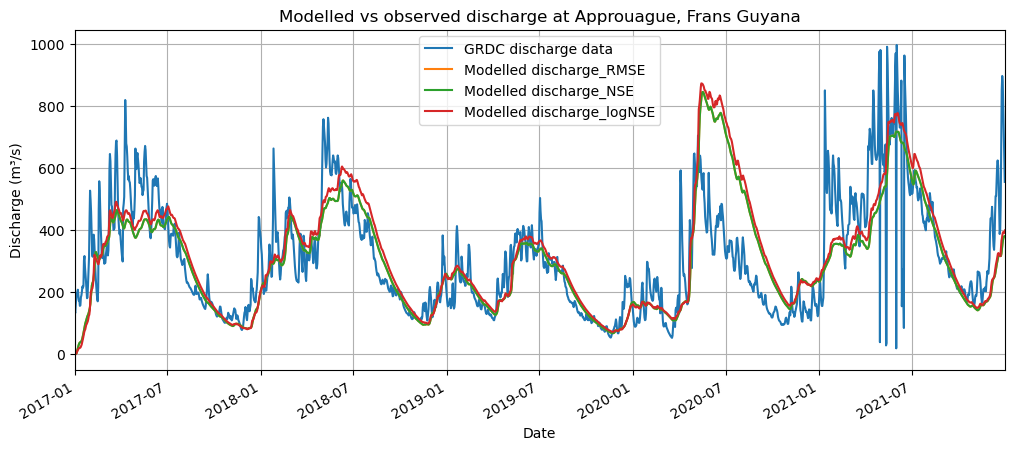

The RMSE paramaters are: [ 0.77241331  0.29269629 79.61362405  0.55344546  0.00757638  4.68474362
  0.016498    0.00616083  0.00000035]
The NSE paramters are: [ 0.77241331  0.29269629 79.61362405  0.55344546  0.00757638  4.68474362
  0.016498    0.00616083  0.00000035]
The logNSE paramters are: [  3.49259766   0.48486438 151.98197183   0.84452696   0.23730761
   1.7826772    0.01668441   0.00572176   0.0000005 ]


In [34]:
plt.figure(figsize=(12, 5))

q_critical = 500

plt.plot(df["Date"], df["Value"], label = "GRDC discharge data")
model_output_m3s_RMSE.plot(label="Modelled discharge_RMSE")
model_output_m3s_NSE.plot(label="Modelled discharge_NSE")
model_output_m3s_logNSE.plot(label="Modelled discharge_logNSE")
# print("grdc = ",df)
# print("model =", model_output_m3s)
# plt.axhline(y=q_critical, linestyle=":", label=f'Critical discharge ({q_critical} m³/s', color='black')

plt.xlabel("Date")
plt.ylabel("Discharge (m³/s)")
plt.title("Modelled vs observed discharge at Approuague, Frans Guyana")
plt.legend()
plt.grid(True)
plt.xlim("2017-01-01", "2021-12-31")

plt.show()

np.set_printoptions(suppress=True)

print(f'The RMSE paramaters are: {parameters_RMSE}')
print(f'The NSE paramters are: {parameters_NSE}')
print(f'The logNSE paramters are: {parameters_logNSE}');

Momenteel worden rmse, nse en lognse allemaal hetzelfde laten zien in de grafiek. Ook lijkt de model output hetzelfde bij alle 3. 